<a href="https://colab.research.google.com/github/Harsh-Raghuvanshi/ActiveDomainAdaptation/blob/v3_main/ResearchModel2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installing Libraries (if not already installed)
!pip install torchvision numpy scikit-learn matplotlib

import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 37.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
# Loading MNIST and USPS Datasets
# Defining transformations for MNIST and USPS

transform = transforms.Compose([
    transforms.Resize((28, 28)),  # Ensure same size
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Load MNIST (source domain)
mnist = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
mnist_test = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Load USPS (target domain)
usps = datasets.USPS(root='./data', train=True, transform=transform, download=True)
usps_test = datasets.USPS(root='./data', train=False, transform=transform, download=True)

# DataLoaders
mnist_loader = DataLoader(mnist, batch_size=64, shuffle=True)
usps_loader = DataLoader(usps, batch_size=64, shuffle=True)


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 54.3MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 2.28MB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



...

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 7.65MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



100%|██████████| 6.58M/6.58M [00:01<00:00, 3.45MB/s]


100%|██████████| 1.83M/1.83M [00:01<00:00, 1.38MB/s]


In [ ]:
transform_svhn = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert RGB to grayscale
    transforms.Resize((28, 28)),  # Ensure same size
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Reload SVHN with the updated transform
svhn = datasets.SVHN(root='./data', split='train', transform=transform_svhn, download=True)
svhn_test = datasets.SVHN(root='./data', split='test', transform=transform_svhn, download=True)

# DataLoaders
svhn_loader = DataLoader(svhn, batch_size=64, shuffle=True)
svhn_test_loader = DataLoader(svhn_test, batch_size=64)


# Get 6000 random indices
random_indices = np.random.choice(len(svhn_test), 6000, replace=False)

# Create a subset dataset with only 6000 random samples
svhn_test_subset = Subset(svhn_test, random_indices)

# Create a DataLoader for the subset
svhn_test_subset_loader = DataLoader(svhn_test_subset, batch_size=64, shuffle=True)

 12%|█▏        | 22.1M/182M [00:05<00:42, 3.75MB/s]


KeyboardInterrupt: 

In [3]:
# Cross Checking availability of data and deciding budget as 10% of target train set size
print("The size of mnist train and test is ", len(mnist), len(mnist_test))
print("The size of usps train and test is ", len(usps), len(usps_test))
# print("The size of svhn train and test is ", len(svhn), len(svhn_test))
# print("The size of svhn subset for test is ",len(svhn_test_subset))
budget = int(700)
print("The budget is : ",budget)

The size of mnist train and test is  60000 10000
The size of usps train and test is  7291 2007
The budget is :  700


In [4]:
# Defining the Simple Convultional neural network Model

import torch.nn as nn
import torch.optim as optim

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)


In [5]:
# Training on MNIST (Source Domain)
x_points = []
y_points = []
def train_source_domain(model, loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        x_points.append(epoch+1)
        y_points.append(running_loss/len(loader))
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(loader)}")

train_source_domain(model, mnist_loader)

# Saving the base model after training for ressting it for various approaches
torch.save(model.state_dict(), '/content/models/base_cnn_model')






Epoch 1/5, Loss: 0.15965761660339076
Epoch 2/5, Loss: 0.04523983023013733
Epoch 3/5, Loss: 0.030754346954387436
Epoch 4/5, Loss: 0.022600023304021655
Epoch 5/5, Loss: 0.017073196873702328


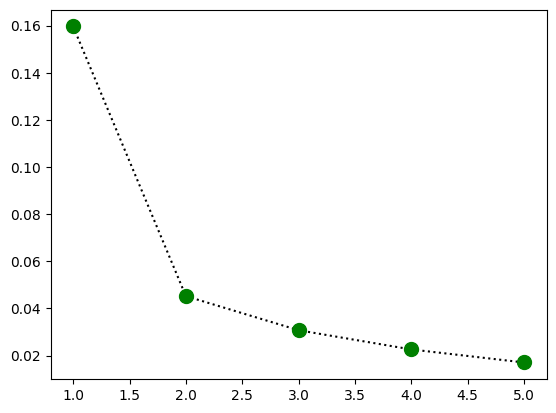

In [6]:
plt.plot(x_points,y_points,marker='o',linestyle='dotted',c='black',ms=10,mfc='green',mec='green');
plt.show()

In [7]:
def resetting_base_model(model_path='/content/models/base_cnn_model'):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SimpleCNN().to(device)
    try:
        model.load_state_dict(torch.load(model_path))
        print(f"Model successfully loaded from {model_path}.")
    except FileNotFoundError:
        print(f"Error: Model checkpoint not found at {model_path}")
        return None
    except Exception as e:
        print(f"Error while resetting model: {e}")
        return None

    model.train()  # Set to training mode for fine-tuning
    return model


In [8]:
# Method Module [ will contain all necessary function for various active domain adaptation techniques]


# Compute Average Uncertainty
def compute_average_uncertainty(model, target_loader):
    model.eval()
    uncertainties = []

    with torch.no_grad():
        for images, _ in target_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            entropy = -torch.sum(probs * torch.log(probs + 1e-5), dim=1)
            uncertainties.extend(entropy.cpu().numpy())

    return np.mean(uncertainties)


# Fine-tuning function
def fine_tune_model(model, loader, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    net_avg_loss=0.0
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        print(f"Fine-tuning Epoch {epoch + 1}/{epochs}, Loss: {running_loss / len(loader)}")
        net_avg_loss+=(running_loss/len(loader))
    return net_avg_loss / epochs


# Uncertainty Sampling
def uncertainty_sampling(model, target_loader, n_samples=100):
    model.eval()
    uncertainties = []
    all_indices = []

    with torch.no_grad():
        for i, (images, _) in enumerate(target_loader):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            entropy = -torch.sum(probs * torch.log(probs + 1e-5), dim=1)
            uncertainties.extend(entropy.cpu().numpy())
            all_indices.extend(range(i * target_loader.batch_size, (i + 1) * target_loader.batch_size))

    # Get indices of top uncertain samples
    uncertain_indices = np.argsort(uncertainties)[-n_samples:]
    return uncertain_indices


# Diversity Sampling
def diversity_sampling(target_data, n_samples=100):
    data = np.array([img.numpy().flatten() for img, _ in target_data])
    kmeans = KMeans(n_clusters=n_samples).fit(data)
    cluster_centers = kmeans.cluster_centers_
    indices, _ = pairwise_distances_argmin_min(cluster_centers, data)
    return indices


# Evaluating model
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy


In [9]:
font_label={'color':'darkblue','size':10}
font_tittle={'color':'black','size':15}


In [10]:

# Active Domain Adaptation using Uncertainity sampling with Fixed Budget

def active_domain_adaptation_with_uncertainity_sampling(
    model, target_loader, target_data, budget, n_iterations=5, batch_size=100
):
    x_points=[]
    y_points=[]
    labeled_samples = 0  # Track the total labeled samples
    total_samples = len(target_data)
    selected_indices = set()  # To avoid duplicate selections

    for iteration in range(n_iterations):
        if labeled_samples >= budget:
            print(f"Budget exhausted after {labeled_samples} samples.")
            break

        remaining_budget = budget - labeled_samples
        current_batch = min(batch_size, remaining_budget)  # Adjust batch size if close to budget

        print(f"Iteration {iteration + 1}: Sampling with weights - Uncertainty")

        # Perform Uncertainty Sampling
        uncertain_indices = uncertainty_sampling(model, target_loader, n_samples=current_batch)
        uncertain_indices = [idx for idx in uncertain_indices if idx not in selected_indices]


        # Combine Uncertainty and Diversity with Dynamic Weights
        combined_indices = (
            uncertain_indices[: int(current_batch)]
        )

        combined_indices = list(set(combined_indices))  # Remove duplicates
        selected_indices.update(combined_indices)

        # Update labeled samples
        labeled_samples += len(combined_indices)
        print(f"Iteration {iteration + 1}: Selected {len(combined_indices)} samples. Total labeled: {labeled_samples}/{budget}")

        # Fine-tune model on selected samples
        selected_data = Subset(target_data, combined_indices)
        selected_loader = DataLoader(selected_data, batch_size=32, shuffle=True)
        y_points.append(fine_tune_model(model, selected_loader))
        x_points.append(iteration+1)


    print("Active Domain Adaptation with Uncertainity Sampling completed.")
    plt.plot(x_points,y_points,marker='o',linestyle='dotted',c='black',ms=10,mfc='green',mec='green');
    plt.grid(axis='x',linestyle=':',color='black')
    plt.grid(axis='y',linestyle=':',color='black')
    plt.xlabel('Iteration',fontdict=font_label)
    plt.ylabel('Loss',fontdict=font_label)
    plt.title('uncertainity_sampling',fontdict=font_tittle)
    plt.show()



In [11]:
#Active Domain adaptation using Diversity sampling with fixed Budget

def active_domain_adaptation_with_diversity_sampling(
    model, target_loader, target_data, budget, n_iterations=5, batch_size=100):
    x_points=[]
    y_points=[]
    labeled_samples = 0  # Track the total labeled samples
    total_samples = len(target_data)
    selected_indices = set()  # To avoid duplicate selections

    for iteration in range(n_iterations):
        if labeled_samples >= budget:
            print(f"Budget exhausted after {labeled_samples} samples.")
            break
        remaining_budget = budget - labeled_samples
        current_batch = min(batch_size, remaining_budget)  # Adjust batch size if close to budget

        print(f"Iteration {iteration + 1}: Sampling with weights - Diversity")
        diverse_indices = diversity_sampling(target_data, n_samples=current_batch)
        diverse_indices = [idx for idx in diverse_indices if idx not in selected_indices]
        combined_indices = (
            diverse_indices[: int(current_batch)]
        )

        combined_indices = list(set(combined_indices))  # Remove duplicates
        selected_indices.update(combined_indices)
        labeled_samples += len(combined_indices)
        print(f"Iteration {iteration + 1}: Selected {len(combined_indices)} samples. Total labeled: {labeled_samples}/{budget}")
        selected_data = Subset(target_data, combined_indices)
        selected_loader = DataLoader(selected_data, batch_size=32, shuffle=True)
        y_points.append(fine_tune_model(model, selected_loader))
        x_points.append(iteration+1)

    print("Active Domain Adaptation with Diversity Sampling completed.")
    plt.plot(x_points,y_points,marker='o',linestyle='dotted',c='black',ms=10,mfc='green',mec='green');
    plt.grid(axis='x',linestyle=':',color='black')
    plt.grid(axis='y',linestyle=':',color='black')
    plt.xlabel('Iteration',fontdict=font_label)
    plt.ylabel('Loss',fontdict=font_label)
    plt.title('diversity_sampling',fontdict=font_tittle)
    plt.show()



In [12]:
# Adaptive Active Domain Adaptation using Hybrid approach with Fixed Budget

def active_domain_adaptation_with_fixed_weighting(
    model, target_loader, target_data, budget, n_iterations=5, batch_size=100
):
    x_points=[]
    y_points=[]
    labeled_samples = 0  # Track the total labeled samples
    total_samples = len(target_data)
    selected_indices = set()  # To avoid duplicate selections

    for iteration in range(n_iterations):
        if labeled_samples >= budget:
            print(f"Budget exhausted after {labeled_samples} samples.")
            break

        remaining_budget = budget - labeled_samples
        current_batch = min(batch_size, remaining_budget)  # Adjust batch size if close to budget

        # Adjust weights based on uncertainty reduction
        if n_iterations//2 < iteration:
          weight_uncertainty = 1
          weight_diversity = 0
        else:
          weight_uncertainty = 0
          weight_diversity = 1

        print(f"Iteration {iteration + 1}: Sampling with weights - Uncertainty: {weight_uncertainty}, Diversity: {weight_diversity}")

        # Perform Uncertainty Sampling
        uncertain_indices = uncertainty_sampling(model, target_loader, n_samples=current_batch)
        uncertain_indices = [idx for idx in uncertain_indices if idx not in selected_indices]

        # Perform Diversity Sampling
        diverse_indices = diversity_sampling(target_data, n_samples=current_batch)
        diverse_indices = [idx for idx in diverse_indices if idx not in selected_indices]

        # Combine Uncertainty and Diversity with Dynamic Weights
        combined_indices = (
            uncertain_indices[: int(current_batch * weight_uncertainty)]
            + diverse_indices[: int(current_batch * weight_diversity)]
        )

        combined_indices = list(set(combined_indices))  # Remove duplicates
        selected_indices.update(combined_indices)

        # Update labeled samples
        labeled_samples += len(combined_indices)
        print(f"Iteration {iteration + 1}: Selected {len(combined_indices)} samples. Total labeled: {labeled_samples}/{budget}")

        # Fine-tune model on selected samples
        selected_data = Subset(target_data, combined_indices)
        selected_loader = DataLoader(selected_data, batch_size=32, shuffle=True)
        y_points.append(fine_tune_model(model, selected_loader))
        x_points.append(iteration+1)

    print("Active Domain Adaptation with Dynamic Weighting completed.")
    plt.plot(x_points,y_points,marker='o',linestyle='dotted',c='black',ms=10,mfc='green',mec='green');
    plt.grid(axis='x',linestyle=':',color='black')
    plt.grid(axis='y',linestyle=':',color='black')
    plt.xlabel('Iteration',fontdict=font_label)
    plt.ylabel('Loss',fontdict=font_label)
    plt.title('static_weighted',fontdict=font_tittle)
    plt.show()



In [22]:
# Adaptive Active Domain Adaptation with Dynamic Budget Allocation

def active_domain_adaptation_with_dynamic_weighting(
    model, target_loader, target_data, budget, n_iterations=5, batch_size=100
):
    x_points=[]
    y_points=[]
    labeled_samples = 0  # Track the total labeled samples
    total_samples = len(target_data)
    selected_indices = set()  # To avoid duplicate selections

    weight_uncertainty = 0.9  # Start with high weight on uncertainty sampling
    weight_diversity = 0.1

    for iteration in range(n_iterations):
        if labeled_samples >= budget:
            print(f"Budget exhausted after {labeled_samples} samples.")
            break

        remaining_budget = budget - labeled_samples
        current_batch = min(batch_size, remaining_budget)  # Adjust batch size if close to budget

        print(f"Iteration {iteration + 1}: Sampling with weights - Uncertainty: {weight_uncertainty}, Diversity: {weight_diversity}")

        # Perform Uncertainty Sampling
        uncertain_indices = uncertainty_sampling(model, target_loader, n_samples=current_batch)
        uncertain_indices = [idx for idx in uncertain_indices if idx not in selected_indices]

        # Perform Diversity Sampling
        diverse_indices = diversity_sampling(target_data, n_samples=current_batch)
        diverse_indices = [idx for idx in diverse_indices if idx not in selected_indices]

        # Combine Uncertainty and Diversity with Dynamic Weights
        combined_indices = (
            uncertain_indices[: int(current_batch * weight_uncertainty)]
            + diverse_indices[: int(current_batch * weight_diversity)]
        )

        combined_indices = list(set(combined_indices))  # Remove duplicates
        selected_indices.update(combined_indices)

        # Update labeled samples
        labeled_samples += len(combined_indices)
        print(f"Iteration {iteration + 1}: Selected {len(combined_indices)} samples. Total labeled: {labeled_samples}/{budget}")

        # Fine-tune model on selected samples
        selected_data = Subset(target_data, combined_indices)
        selected_loader = DataLoader(selected_data, batch_size=32, shuffle=True)
        y_points.append(fine_tune_model(model, selected_loader))
        x_points.append(iteration+1)


        # Adjust weights based on uncertainty reduction
        avg_uncertainty = compute_average_uncertainty(model, target_loader)
        print("the uncertainity is now : ",avg_uncertainty)
        if avg_uncertainty < 0.5:  # Example threshold for reducing uncertainty weight
            weight_uncertainty = max(0.1, weight_uncertainty - 0.15)
            weight_diversity = min(0.9, weight_diversity + 0.15)

    print("Active Domain Adaptation with Dynamic Weighting completed...")
    plt.plot(x_points,y_points,marker='o',linestyle='dotted',c='black',ms=10,mfc='green',mec='green');
    plt.grid(axis='x',linestyle=':',color='black')
    plt.grid(axis='y',linestyle=':',color='black')
    plt.xlabel('Iteration',fontdict=font_label)
    plt.ylabel('Loss',fontdict=font_label)
    plt.title('dynamic_weight',fontdict=font_tittle)
    plt.show()



In [24]:
# Adaptive Active Domain Adaptation with Dynamic Budget Allocation Version 2

import numpy as np

def adaptive_threshold(t, initial=0.9, final=0.1, decay_rate=0.10):
    """
    Computes an adaptive threshold for uncertainty weight based on exponential decay.
    :param t: Current iteration
    :param initial: Initial uncertainty weight
    :param final: Minimum allowed uncertainty weight
    :param decay_rate: Controls speed of decay
    :return: Updated uncertainty and diversity weights
    """
    weight_uncertainty = final + (initial - final) * np.exp(-decay_rate * t)
    weight_diversity = 1 - weight_uncertainty  # Ensuring sum is 1
    return weight_uncertainty, weight_diversity

def active_domain_adaptation_with_dynamic_weighting_v2(
    model, target_loader, target_data, budget, n_iterations, batch_size
):
    x_points=[]
    y_points=[]
    labeled_samples = 0  # Tracking the total labeled samples
    total_samples = len(target_data)
    selected_indices = set()  # To avoid duplicate selections

    for iteration in range(n_iterations):
        if labeled_samples >= budget:
            print(f"Budget exhausted after {labeled_samples} samples.")
            break

        remaining_budget = budget - labeled_samples
        current_batch = min(batch_size, remaining_budget)  # Adjusting batch size if close to budget

        # Dynamically computing uncertainty and diversity weights
        weight_uncertainty, weight_diversity = adaptive_threshold(iteration)
        print(f"Iteration {iteration + 1}: Sampling with weights - Uncertainty: {weight_uncertainty:.3f}, Diversity: {weight_diversity:.3f}")

        # Performing Uncertainty Sampling
        uncertain_indices = uncertainty_sampling(model, target_loader, n_samples=current_batch)
        uncertain_indices = [idx for idx in uncertain_indices if idx not in selected_indices]

        # Performing Diversity Sampling
        diverse_indices = diversity_sampling(target_data, n_samples=current_batch)
        diverse_indices = [idx for idx in diverse_indices if idx not in selected_indices]

        # Combining Uncertainty and Diversity with Dynamic Weights
        combined_indices = (
            uncertain_indices[: int(current_batch * weight_uncertainty)]
            + diverse_indices[: int(current_batch * weight_diversity)]
        )

        combined_indices = list(set(combined_indices))  # Remove duplicates
        selected_indices.update(combined_indices)

        # Updating labeled samples
        labeled_samples += len(combined_indices)
        print(f"Iteration {iteration + 1}: Selected {len(combined_indices)} samples. Total labeled: {labeled_samples}/{budget}")

        # Fine-tuning model on selected samples
        selected_data = Subset(target_data, combined_indices)
        selected_loader = DataLoader(selected_data, batch_size=32, shuffle=True)
        y_points.append(fine_tune_model(model, selected_loader))
        x_points.append(iteration+1)

    print("Active Domain Adaptation with Dynamic Weighting completed.")
    plt.plot(x_points,y_points,marker='o',linestyle='dotted',c='black',ms=10,mfc='green',mec='green');
    plt.grid(axis='x',linestyle=':',color='black')
    plt.grid(axis='y',linestyle=':',color='black')
    plt.xlabel('Iteration',fontdict=font_label)
    plt.ylabel('Loss',fontdict=font_label)
    plt.title('dynamic_weight_v2',fontdict=font_tittle)
    plt.show()


In [ ]:
# model=resetting_base_model()
# print("The accuracy for Simple Model is on SVHN : ",end='')
# evaluate_model(model, DataLoader(svhn_test, batch_size=64))
# print()

In [ ]:
# model=resetting_base_model()
# active_domain_adaptation_with_dynamic_weighting(model,svhn_loader, svhn, budget=1000)
# torch.save(model.state_dict(), '/content/models/dynamic_active_cnn_model_svhn')
# print("The accuracy for dynamic weighted active domain adaptation using hybrid approach is : ")
# evaluate_model(model, svhn_test_subset_loader)
# print()

<ipython-input-7-08abd7a43186>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Model successfully loaded from /content/models/base_cnn_model.
The accuracy for Simple Model is :  78.07673143996014

Model successfully loaded from /content/models/base_cnn_model.
Iteration 1: Sampling with weights - Uncertainty
Iteration 1: Selected 70 samples. Total labeled: 70/1000
Fine-tuning Epoch 1/3, Loss: 0.7114760875701904
Fine-tuning Epoch 2/3, Loss: 0.7893169820308685
Fine-tuning Epoch 3/3, Loss: 0.9211263855298361
Iteration 2: Sampling with weights - Uncertainty
Iteration 2: Selected 70 samples. Total labeled: 140/1000
Fine-tuning Epoch 1/3, Loss: 0.2852264617880185
Fine-tuning Epoch 2/3, Loss: 0.33146096269289654
Fine-tuning Epoch 3/3, Loss: 0.2260308340191841
Iteration 3: Sampling with weights - Uncertainty
Iteration 3: Selected 69 samples. Total labeled: 209/1000
Fine-tuning Epoch 1/3, Loss: 0.5801777814825376
Fine-tuning Epoch 2/3, Loss: 0.5805922448635101
Fine-tuning Epoch 3/3, Loss: 0.6720448931058248
Iteration 4: Sampling with weights - Uncertainty
Iteration 4: Sele

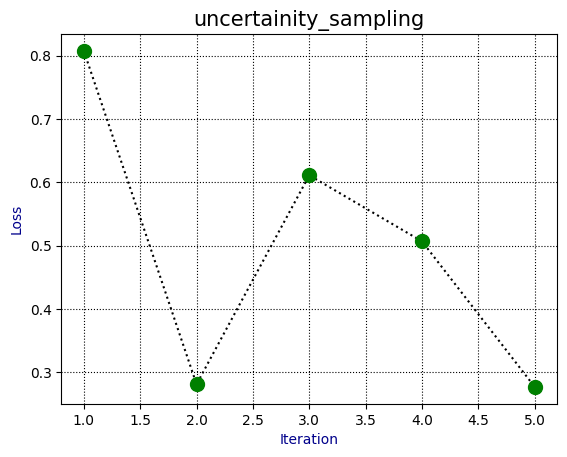

The accuracy for uncertainity active domain adaptation is :  86.04882909815645

Model successfully loaded from /content/models/base_cnn_model.
Iteration 1: Sampling with weights - Diversity
Iteration 1: Selected 70 samples. Total labeled: 70/1000
Fine-tuning Epoch 1/3, Loss: 0.3234799901644389
Fine-tuning Epoch 2/3, Loss: 0.3123063047726949
Fine-tuning Epoch 3/3, Loss: 0.2675686441361904
Iteration 2: Sampling with weights - Diversity
Iteration 2: Selected 58 samples. Total labeled: 128/1000
Fine-tuning Epoch 1/3, Loss: 0.33923453092575073
Fine-tuning Epoch 2/3, Loss: 0.303073950111866
Fine-tuning Epoch 3/3, Loss: 0.26764121651649475
Iteration 3: Sampling with weights - Diversity
Iteration 3: Selected 53 samples. Total labeled: 181/1000
Fine-tuning Epoch 1/3, Loss: 0.30100854113698006
Fine-tuning Epoch 2/3, Loss: 0.3233288452029228
Fine-tuning Epoch 3/3, Loss: 0.28345541656017303
Iteration 4: Sampling with weights - Diversity
Iteration 4: Selected 30 samples. Total labeled: 211/1000
Fin

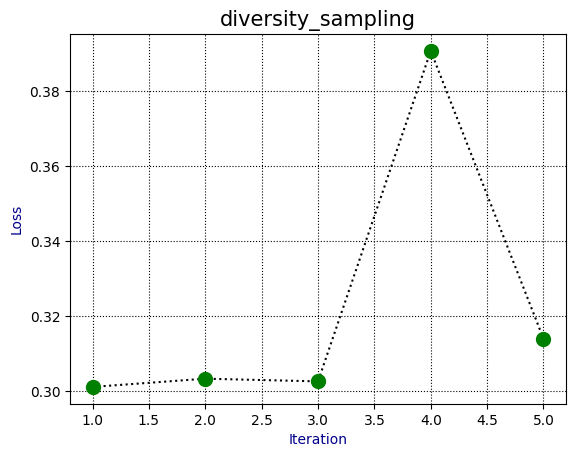

The accuracy for diversity active domain adaptation is :  84.45440956651719

Model successfully loaded from /content/models/base_cnn_model.
Iteration 1: Sampling with weights - Uncertainty: 0, Diversity: 1


<ipython-input-7-08abd7a43186>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Iteration 1: Selected 70 samples. Total labeled: 70/1000
Fine-tuning Epoch 1/3, Loss: 0.3922855257987976
Fine-tuning Epoch 2/3, Loss: 0.3378135959307353
Fine-tuning Epoch 3/3, Loss: 0.2547432805101077
Iteration 2: Sampling with weights - Uncertainty: 0, Diversity: 1
Iteration 2: Selected 59 samples. Total labeled: 129/1000
Fine-tuning Epoch 1/3, Loss: 0.3829132914543152
Fine-tuning Epoch 2/3, Loss: 0.3633184880018234
Fine-tuning Epoch 3/3, Loss: 0.32630979269742966
Iteration 3: Sampling with weights - Uncertainty: 0, Diversity: 1
Iteration 3: Selected 49 samples. Total labeled: 178/1000
Fine-tuning Epoch 1/3, Loss: 0.40959741175174713
Fine-tuning Epoch 2/3, Loss: 0.323940634727478
Fine-tuning Epoch 3/3, Loss: 0.28852540627121925
Iteration 4: Sampling with weights - Uncertainty: 1, Diversity: 0
Iteration 4: Selected 69 samples. Total labeled: 247/1000
Fine-tuning Epoch 1/3, Loss: 0.3347177604834239
Fine-tuning Epoch 2/3, Loss: 0.32554083069165546
Fine-tuning Epoch 3/3, Loss: 0.335650324

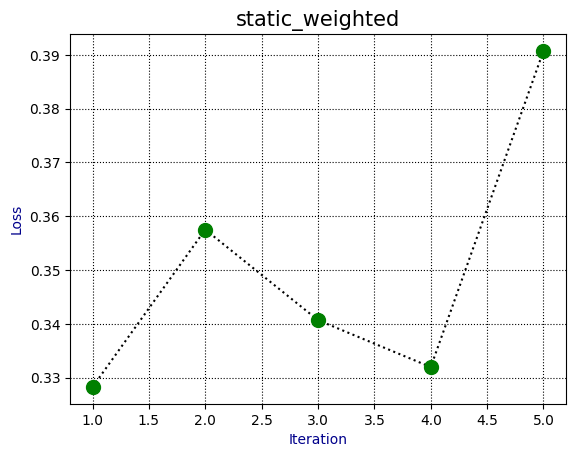

The accuracy for static weighted active domain adaptation using hybrid approach is :  86.84603886397609

Model successfully loaded from /content/models/base_cnn_model.
Iteration 1: Sampling with weights - Uncertainty: 0.9, Diversity: 0.1


<ipython-input-7-08abd7a43186>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Iteration 1: Selected 70 samples. Total labeled: 70/1000
Fine-tuning Epoch 1/3, Loss: 0.4430028299490611
Fine-tuning Epoch 2/3, Loss: 0.5993775725364685
Fine-tuning Epoch 3/3, Loss: 0.3825240929921468
the uncertainity is now :  0.6171061
Iteration 2: Sampling with weights - Uncertainty: 0.9, Diversity: 0.1
Iteration 2: Selected 70 samples. Total labeled: 140/1000
Fine-tuning Epoch 1/3, Loss: 0.42012373358011246
Fine-tuning Epoch 2/3, Loss: 0.489831139643987
Fine-tuning Epoch 3/3, Loss: 0.42641234397888184
the uncertainity is now :  0.5892998
Iteration 3: Sampling with weights - Uncertainty: 0.9, Diversity: 0.1
Iteration 3: Selected 70 samples. Total labeled: 210/1000
Fine-tuning Epoch 1/3, Loss: 0.43618955711523694
Fine-tuning Epoch 2/3, Loss: 0.5300330221652985
Fine-tuning Epoch 3/3, Loss: 0.6595122416814169
the uncertainity is now :  0.5521969
Iteration 4: Sampling with weights - Uncertainty: 0.9, Diversity: 0.1
Iteration 4: Selected 70 samples. Total labeled: 280/1000
Fine-tuning Ep

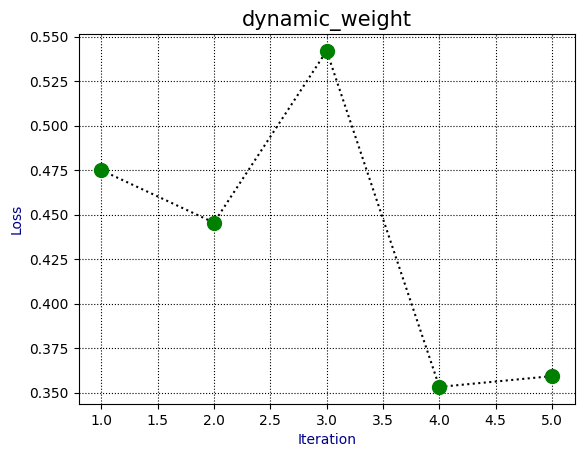

The accuracy for dynamic weighted active domain adaptation using hybrid approach is :  86.6965620328849

Model successfully loaded from /content/models/base_cnn_model.
Iteration 1: Sampling with weights - Uncertainty: 0.900, Diversity: 0.100


<ipython-input-7-08abd7a43186>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Iteration 1: Selected 69 samples. Total labeled: 69/1000
Fine-tuning Epoch 1/3, Loss: 0.7255046963691711
Fine-tuning Epoch 2/3, Loss: 0.6953146656354269
Fine-tuning Epoch 3/3, Loss: 0.5693610236048698
Iteration 2: Sampling with weights - Uncertainty: 0.824, Diversity: 0.176
Iteration 2: Selected 69 samples. Total labeled: 138/1000
Fine-tuning Epoch 1/3, Loss: 0.5244853595892588
Fine-tuning Epoch 2/3, Loss: 0.43872369329134625
Fine-tuning Epoch 3/3, Loss: 0.7246508896350861
Iteration 3: Sampling with weights - Uncertainty: 0.755, Diversity: 0.245
Iteration 3: Selected 69 samples. Total labeled: 207/1000
Fine-tuning Epoch 1/3, Loss: 0.45421184102694195
Fine-tuning Epoch 2/3, Loss: 0.390831117828687
Fine-tuning Epoch 3/3, Loss: 0.7249214351177216
Iteration 4: Sampling with weights - Uncertainty: 0.693, Diversity: 0.307
Iteration 4: Selected 69 samples. Total labeled: 276/1000
Fine-tuning Epoch 1/3, Loss: 0.39158424735069275
Fine-tuning Epoch 2/3, Loss: 0.433482567469279
Fine-tuning Epoch 

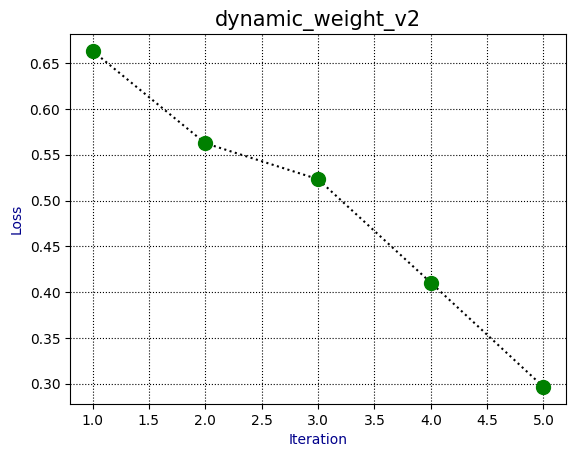

The accuracy for dynamic weighted active domain adaptation using hybrid approach V2 is :  87.39412057797708



In [26]:

x_model_name=[]
y_model_acc=[]



model=resetting_base_model()
simple_acc=evaluate_model(model, DataLoader(usps_test, batch_size=64))
print("The accuracy for Simple Model is : ",simple_acc)
print()

x_model_name.append('Simple Model')
y_model_acc.append(simple_acc)




budget=1000
n_iterations=5
batch_size=70



model=resetting_base_model()
active_domain_adaptation_with_uncertainity_sampling(model, usps_loader, usps, budget,n_iterations,batch_size)
torch.save(model.state_dict(), '/content/models/uncertainity_active_cnn_model')
uncertainity_acc=evaluate_model(model, DataLoader(usps_test, batch_size=64))
print("The accuracy for uncertainity active domain adaptation is : ",uncertainity_acc)
print()

x_model_name.append('Uncertainity Active Model')
y_model_acc.append(uncertainity_acc)

model=resetting_base_model()
active_domain_adaptation_with_diversity_sampling(model, usps_loader, usps, budget,n_iterations,batch_size)
torch.save(model.state_dict(), '/content/models/diversity_active_cnn_model')
diversity_acc=evaluate_model(model, DataLoader(usps_test, batch_size=64))
print("The accuracy for diversity active domain adaptation is : ",diversity_acc)
print()

x_model_name.append('Diversity Active Model')
y_model_acc.append(diversity_acc)


model=resetting_base_model()
active_domain_adaptation_with_fixed_weighting(model, usps_loader, usps, budget,n_iterations,batch_size)
torch.save(model.state_dict(), '/content/models/static_active_cnn_model')
static_weighted_acc=evaluate_model(model, DataLoader(usps_test, batch_size=64))
print("The accuracy for static weighted active domain adaptation using hybrid approach is : ",static_weighted_acc)
print()

x_model_name.append('Static Weighted Active Model')
y_model_acc.append(static_weighted_acc)



model=resetting_base_model()
active_domain_adaptation_with_dynamic_weighting(model, usps_loader, usps, budget,n_iterations,batch_size)
torch.save(model.state_dict(), '/content/models/dynamic_active_cnn_model')
dynamic_weightedv1_acc=evaluate_model(model, DataLoader(usps_test, batch_size=64))
print("The accuracy for dynamic weighted active domain adaptation using hybrid approach is : ",dynamic_weightedv1_acc)
print()

x_model_name.append('Dynamic Weighted Active Model')
y_model_acc.append(dynamic_weightedv1_acc)


model=resetting_base_model()
active_domain_adaptation_with_dynamic_weighting_v2(model, usps_loader, usps, budget,n_iterations,batch_size)
torch.save(model.state_dict(), '/content/models/dynamic_active_cnn_model_v2')
dynamic_weightedv2_acc=evaluate_model(model, DataLoader(usps_test, batch_size=64))
print("The accuracy for dynamic weighted active domain adaptation using hybrid approach V2 is : ",dynamic_weightedv2_acc)
print()

x_model_name.append('Dynamic Weighted Active Model V2')
y_model_acc.append(dynamic_weightedv2_acc)




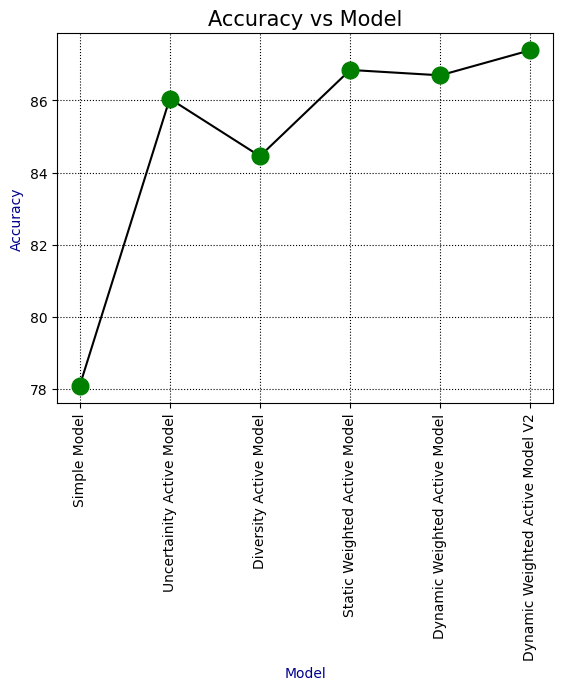

In [27]:
plt.plot(x_model_name,y_model_acc,marker='o',linestyle='-',mfc='green',mec='green',color='black',ms=12)
plt.xlabel('Model',fontdict=font_label)
plt.ylabel('Accuracy',fontdict=font_label)
plt.title('Accuracy vs Model',fontdict=font_tittle)
plt.grid(axis='x',linestyle=':',color='black')
plt.grid(axis='y',linestyle=':',color='black')
plt.xticks(rotation=90)
plt.show()


<ipython-input-7-08abd7a43186>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Model successfully loaded from /content/models/base_cnn_model.
Iteration 1: Sampling with weights - Uncertainty: 0.900, Diversity: 0.100
Iteration 1: Selected 69 samples. Total labeled: 69/1000
Fine-tuning Epoch 1/3, Loss: 0.5455064790633818
Fine-tuning Epoch 2/3, Loss: 0.7027486364046732
Fine-tuning Epoch 3/3, Loss: 0.7831021745999655
Iteration 2: Sampling with weights - Uncertainty: 0.824, Diversity: 0.176
Iteration 2: Selected 69 samples. Total labeled: 138/1000
Fine-tuning Epoch 1/3, Loss: 0.36265989268819493
Fine-tuning Epoch 2/3, Loss: 0.3376433526476224
Fine-tuning Epoch 3/3, Loss: 0.30498504887024563
Iteration 3: Sampling with weights - Uncertainty: 0.755, Diversity: 0.245
Iteration 3: Selected 69 samples. Total labeled: 207/1000
Fine-tuning Epoch 1/3, Loss: 0.4418596824010213
Fine-tuning Epoch 2/3, Loss: 0.4734232723712921
Fine-tuning Epoch 3/3, Loss: 0.34927455087502796
Iteration 4: Sampling with weights - Uncertainty: 0.693, Diversity: 0.307
Iteration 4: Selected 69 samples.

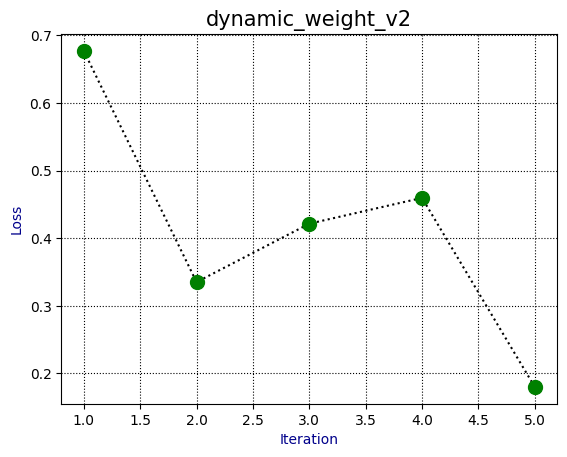

The accuracy for dynamic weighted active domain adaptation using hybrid approach is :  87.29446935724962



In [25]:
model=resetting_base_model()
active_domain_adaptation_with_dynamic_weighting_v2(model, usps_loader, usps, budget,n_iterations,batch_size)
torch.save(model.state_dict(), '/content/models/dynamic_active_cnn_model')
dynamic_weightedv1_acc=evaluate_model(model, DataLoader(usps_test, batch_size=64))
print("The accuracy for dynamic weighted active domain adaptation using hybrid approach is : ",dynamic_weightedv1_acc)
print()